# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Ulum Hikam
- **Email:** hkmfile@gmail.com
- **ID Dicoding:** ulum_hikam_gkfq

## Menentukan Pertanyaan Bisnis

Pertanyaan 1: Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi dan memiliki volume penjualan terbanyak selama periode tahun 2017 hingga 2018?

Pertanyaan 2: Bagaimana perbandingan skor kepuasan pelanggan (review score) antar negara bagian (state) dan apakah terdapat korelasi antara durasi pengiriman dengan skor yang diberikan oleh pelanggan?

## Import Semua Packages/Library yang Digunakan

In [26]:
import pandas as pd
import matplotlib
import seaborn as sns
import datetime as dt

print(f"Versi Pandas: {pd.__version__}")
print(f"Versi Matplotlib: {matplotlib.__version__}")
print(f"Versi Seaborn: {sns.__version__}")

Versi Pandas: 2.2.2
Versi Matplotlib: 3.10.0
Versi Seaborn: 0.13.2


In [28]:
!pip show pandas

Name: pandas
Version: 2.2.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be u

In [29]:
!pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [30]:
!pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, pandas
Required-by: missingno, segregation, splot


## Data Wrangling

### Gathering Data

In [2]:
# Tentukan path folder
path = "dataset_awal/"

# Memuat semua dataset yang diperlukan untuk 2 pertanyaan SMART
customers_df = pd.read_csv(path + "olist_customers_dataset.csv")
orders_df = pd.read_csv(path + "olist_orders_dataset.csv")
order_items_df = pd.read_csv(path + "olist_order_items_dataset.csv")
order_reviews_df = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products_df = pd.read_csv(path + "olist_products_dataset.csv")
category_translation_df = pd.read_csv(path + "product_category_name_translation.csv")

# Menampilkan konfirmasi dan ringkasan singkat data
print("Status: Semua data berhasil dimuat dari folder 'dataset_awal/'")
print(f"Jumlah baris Orders: {orders_df.shape[0]}")
print(f"Jumlah baris Customers: {customers_df.shape[0]}")

# Menampilkan 5 data teratas dari orders_df sebagai verifikasi awal
orders_df.head()

Status: Semua data berhasil dimuat dari folder 'dataset_awal/'
Jumlah baris Orders: 99441
Jumlah baris Customers: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- xxx
- xxx

### Assessing Data

In [3]:
print("--- Memeriksa customers_df ---")
print(customers_df.info())
print("Jumlah Missing Values:\n", customers_df.isna().sum())
print("Jumlah Duplikasi:", customers_df.duplicated().sum())

--- Memeriksa customers_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
Jumlah Missing Values:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Jumlah Duplikasi: 0


In [4]:
print("\n--- Memeriksa orders_df ---")
print(orders_df.info())
print("Jumlah Missing Values:\n", orders_df.isna().sum())
print("Jumlah Duplikasi:", orders_df.duplicated().sum())


--- Memeriksa orders_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
Jumlah Missing Values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivere

In [5]:
print("\n--- Memeriksa order_items_df ---")
print(order_items_df.info())
print("Statistik Deskriptif:\n", order_items_df.describe())
print("Jumlah Duplikasi:", order_items_df.duplicated().sum())


--- Memeriksa order_items_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None
Statistik Deskriptif:
        order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
5

In [6]:
print("\n--- Memeriksa order_reviews_df ---")
print(order_reviews_df.info())
print("Jumlah Missing Values:\n", order_reviews_df.isna().sum())
print("Statistik Skor Review:\n", order_reviews_df['review_score'].describe())


--- Memeriksa order_reviews_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None
Jumlah Missing Values:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Statistik Skor Review:
 count    99224.000000
mean      

In [7]:
print("\n--- Memeriksa products_df ---")
print(products_df.info())
print("Jumlah Missing Values:\n", products_df.isna().sum())

print("\n--- Memeriksa category_translation_df ---")
print(category_translation_df.info())


--- Memeriksa products_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None
Jumlah Missing Values:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qt

**Insight:**
- xxx
- xxx

### Cleaning Data

In [8]:
# Memperbaiki Tipe Data Tanggal
# Kita akan mengubah kolom yang berisi informasi waktu dari tipe object menjadi datetime.

# Kolom yang harus diubah menjadi datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Mengonversi tipe data di orders_df
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Mengonversi shipping_limit_date di order_items_df
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

# Verifikasi perubahan
print("Tipe data orders_df:\n", orders_df.dtypes)

Tipe data orders_df:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [9]:
# Menangani Missing Values
# Kita akan melakukan imputasi (pengisian data) pada kategori produk yang kosong dan membiarkan kolom tanggal pengiriman yang kosong (karena bermakna pesanan belum sampai/batal).

# Mengisi missing values pada product_category_name dengan 'others'
products_df["product_category_name"] = products_df["product_category_name"].fillna(value="others")

# Memastikan tidak ada lagi missing values di kategori produk
print(f"Missing values di products_df setelah cleaning: {products_df['product_category_name'].isna().sum()}")

Missing values di products_df setelah cleaning: 0


In [10]:
# Memfilter Data Sesuai Periode (2017 - 2018)
# Sesuai Pertanyaan SMART 1, kita hanya akan fokus pada transaksi di tahun 2017 dan 2018.

# Filter data orders hanya untuk tahun 2017 dan 2018
orders_df = orders_df[(orders_df["order_purchase_timestamp"].dt.year >= 2017) &
                     (orders_df["order_purchase_timestamp"].dt.year <= 2018)]

print(f"Jumlah data setelah difilter (2017-2018): {orders_df.shape[0]} baris")

Jumlah data setelah difilter (2017-2018): 99112 baris


**Insight:**
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

In [11]:
# Eksplorasi customers_df
# Kita ingin melihat persebaran pelanggan berdasarkan lokasi (Negara Bagian/State).

# Melihat rangkuman parameter statistik data pelanggan
print(customers_df.describe(include="all"))

# Melihat persebaran pelanggan berdasarkan state
customers_by_state = customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)
print("\nPersebaran Pelanggan per Negara Bagian:")
print(customers_by_state)

                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     274fa6071e5e17fe303b9748641082c8  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_prefix customer_city customer_state  

In [12]:
# Eksplorasi orders_df
# Kita akan melihat status pesanan dan tren waktu pembelian.

# Melihat status pesanan terbanyak
order_status_counts = orders_df["order_status"].value_counts()
print("Distribusi Status Pesanan:")
print(order_status_counts)

# Menghitung lama pengiriman (delivery time) dalam hari
orders_df["delivery_time"] = (orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]).dt.days

# Statistik deskriptif untuk lama pengiriman
print("\nStatistik Lama Pengiriman (Hari):")
print(orders_df["delivery_time"].describe())

Distribusi Status Pesanan:
order_status
delivered      96211
shipped         1098
unavailable      602
canceled         599
processing       299
invoiced         296
created            5
approved           2
Name: count, dtype: int64

Statistik Lama Pengiriman (Hari):
count    96204.000000
mean        12.074041
std          9.535667
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64


In [13]:
# Eksplorasi order_items_df & products_df
# Mengenali rentang harga dan kategori produk.

# Statistik deskriptif harga dan ongkos kirim
print("Statistik Harga & Ongkir:")
print(order_items_df[["price", "freight_value"]].describe())

# Menggabungkan products_df dengan category_translation_df agar nama kategori dalam Bahasa Inggris
products_translated_df = pd.merge(
    left=products_df,
    right=category_translation_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Jika ada yang tidak terjemahkan, isi dengan nama kategori aslinya atau 'others'
products_translated_df["product_category_name_english"] = products_translated_df["product_category_name_english"].fillna(products_translated_df["product_category_name"])

print("\nSample Data Produk Terjemahan:")
print(products_translated_df[["product_id", "product_category_name_english"]].head())

Statistik Harga & Ongkir:
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

Sample Data Produk Terjemahan:
                         product_id product_category_name_english
0  1e9e8ef04dbcff4541ed26657ea517e5                     perfumery
1  3aa071139cb16b67ca9e5dea641aaa2f                           art
2  96bd76ec8810374ed1b65e291975717f                sports_leisure
3  cef67bcfe19066a932b7673e239eb23d                          baby
4  9dc1a7de274444849c219cff195d0b71                    housewares


In [14]:
# Eksplorasi order_reviews_df
# Melihat distribusi tingkat kepuasan pelanggan.

# Distribusi skor review
review_counts = order_reviews_df["review_score"].value_counts().sort_index(ascending=False)
print("Distribusi Skor Review (1-5):")
print(review_counts)

Distribusi Skor Review (1-5):
review_score
5    57328
4    19142
3     8179
2     3151
1    11424
Name: count, dtype: int64


In [15]:
#sekarang, kita gabungkan semua tabel menjadi satu DataFrame besar (all_df) agar bisa menjawab pertanyaan SMART secara komprehensif.

# 1. Menggabungkan orders dengan order_items
orders_items_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# 2. Menggabungkan dengan products_translated_df
orders_products_df = pd.merge(
    left=orders_items_df,
    right=products_translated_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# 3. Menggabungkan dengan customers_df
orders_customers_df = pd.merge(
    left=orders_products_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# 4. Menggabungkan dengan order_reviews_df
all_df = pd.merge(
    left=orders_customers_df,
    right=order_reviews_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

print("Status: Semua data telah berhasil digabungkan ke dalam 'all_df'")
all_df.head()

Status: Semua data telah berhasil digabungkan ke dalam 'all_df'


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_item_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1.0,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1.0,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,1.0,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,1.0,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [16]:
# Menyimpan all_df ke dalam folder dataset_awal dengan nama olist_final_dataset.csv
all_df.to_csv("dataset_awal/olist_final_dataset.csv", index=False)

print("Status: Data gabungan berhasil disimpan di 'dataset_awal/olist_final_dataset.csv'")

Status: Data gabungan berhasil disimpan di 'dataset_awal/olist_final_dataset.csv'


**Insight:**
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi dan memiliki volume penjualan terbanyak selama periode tahun 2017 hingga 2018?

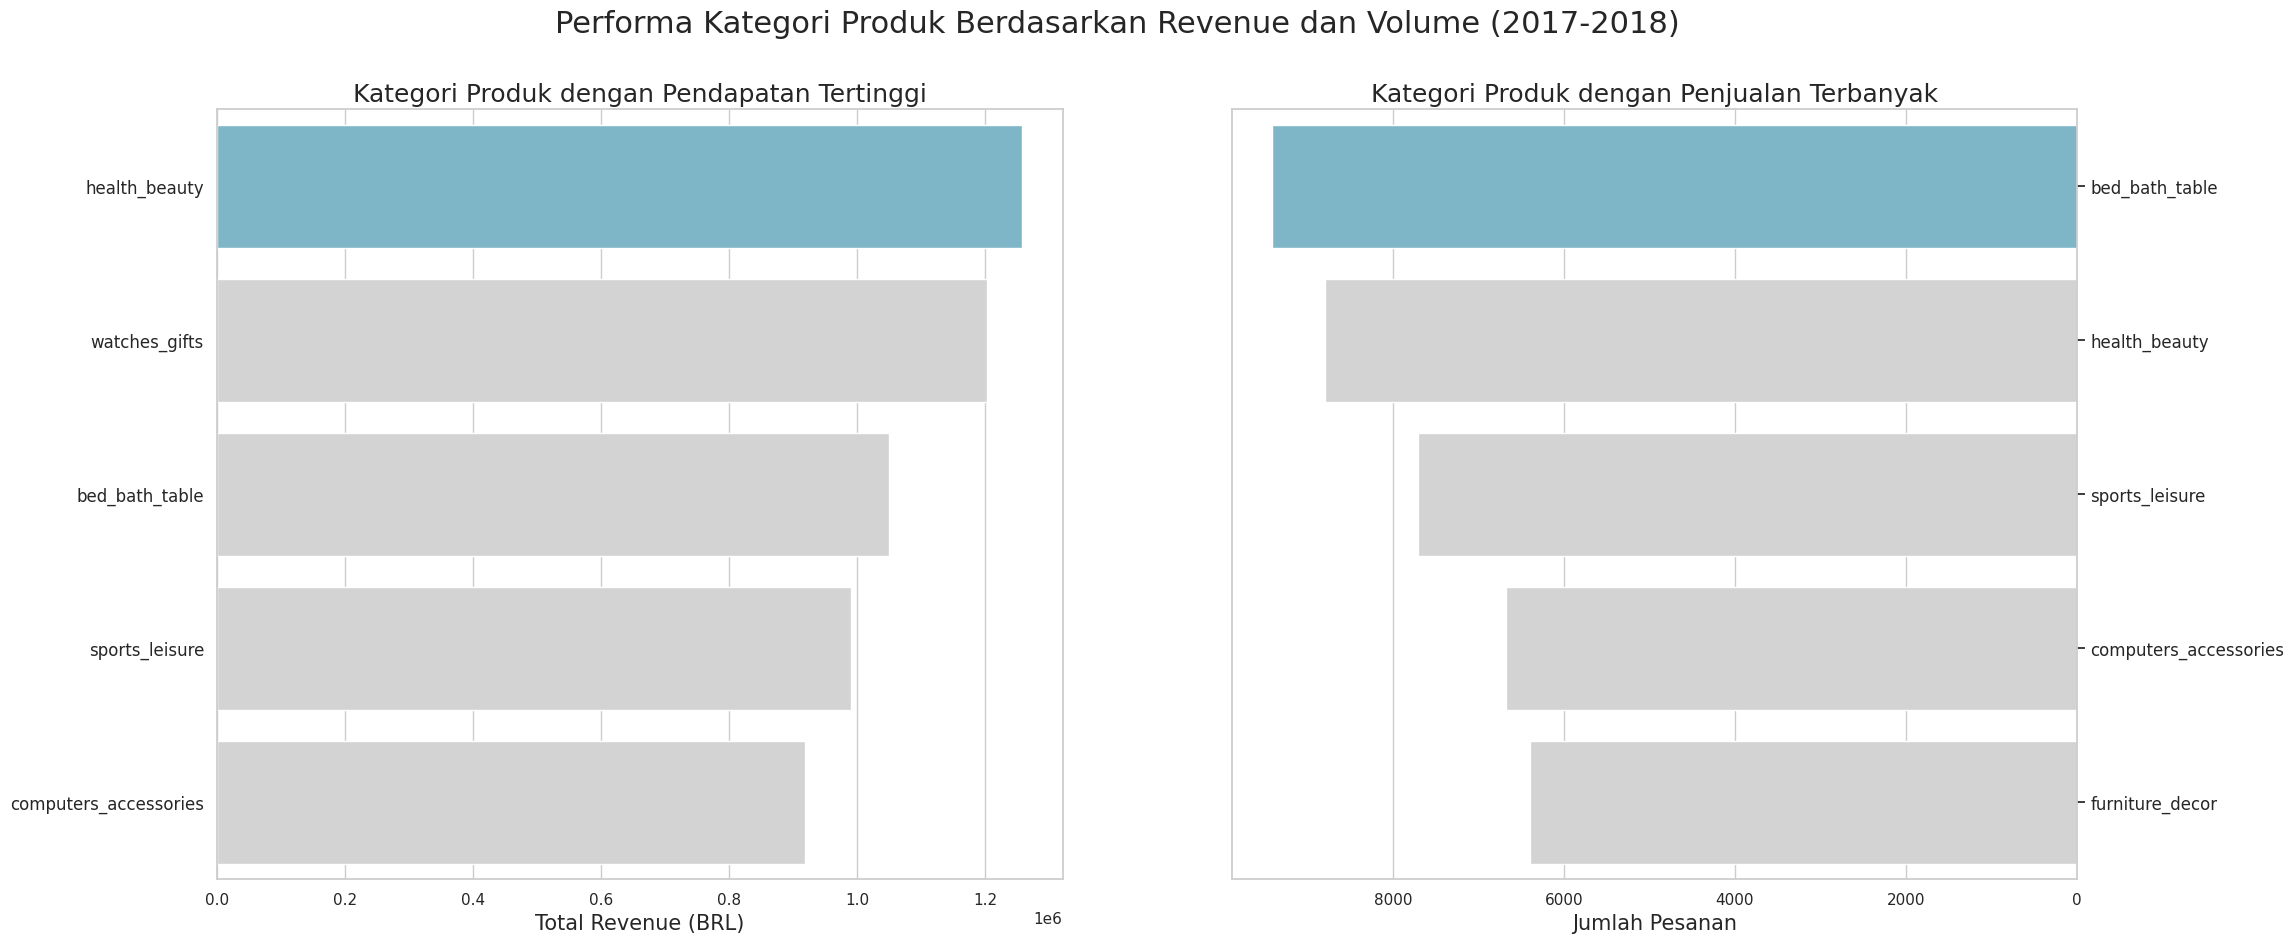

In [17]:
# 1. Menyiapkan data untuk Pertanyaan 1
category_analysis_df = all_df.groupby("product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

category_analysis_df.rename(columns={
    "order_id": "order_count",
    "price": "total_revenue"
}, inplace=True)

# 2. Membuat visualisasi dengan Subplots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Bar Chart 1: Berdasarkan Total Revenue
sns.barplot(
    x="total_revenue",
    y="product_category_name_english",
    data=category_analysis_df.sort_values(by="total_revenue", ascending=False).head(5),
    palette=colors,
    hue="product_category_name_english", # PERBAIKAN: Tambahkan hue
    legend=False,                        # PERBAIKAN: Tambahkan legend=False
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Revenue (BRL)", fontsize=15)
ax[0].set_title("Kategori Produk dengan Pendapatan Tertinggi", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=12)

# Bar Chart 2: Berdasarkan Volume Penjualan (Order Count)
sns.barplot(
    x="order_count",
    y="product_category_name_english",
    data=category_analysis_df.sort_values(by="order_count", ascending=False).head(5),
    palette=colors,
    hue="product_category_name_english", # PERBAIKAN: Tambahkan hue
    legend=False,                        # PERBAIKAN: Tambahkan legend=False
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Jumlah Pesanan", fontsize=15)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori Produk dengan Penjualan Terbanyak", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Performa Kategori Produk Berdasarkan Revenue dan Volume (2017-2018)", fontsize=22)
plt.show()

### Pertanyaan 2: Bagaimana tingkat kepuasan pelanggan (review score) di berbagai wilayah, dan apakah terdapat korelasi antara lama waktu pengiriman dengan skor yang diberikan?

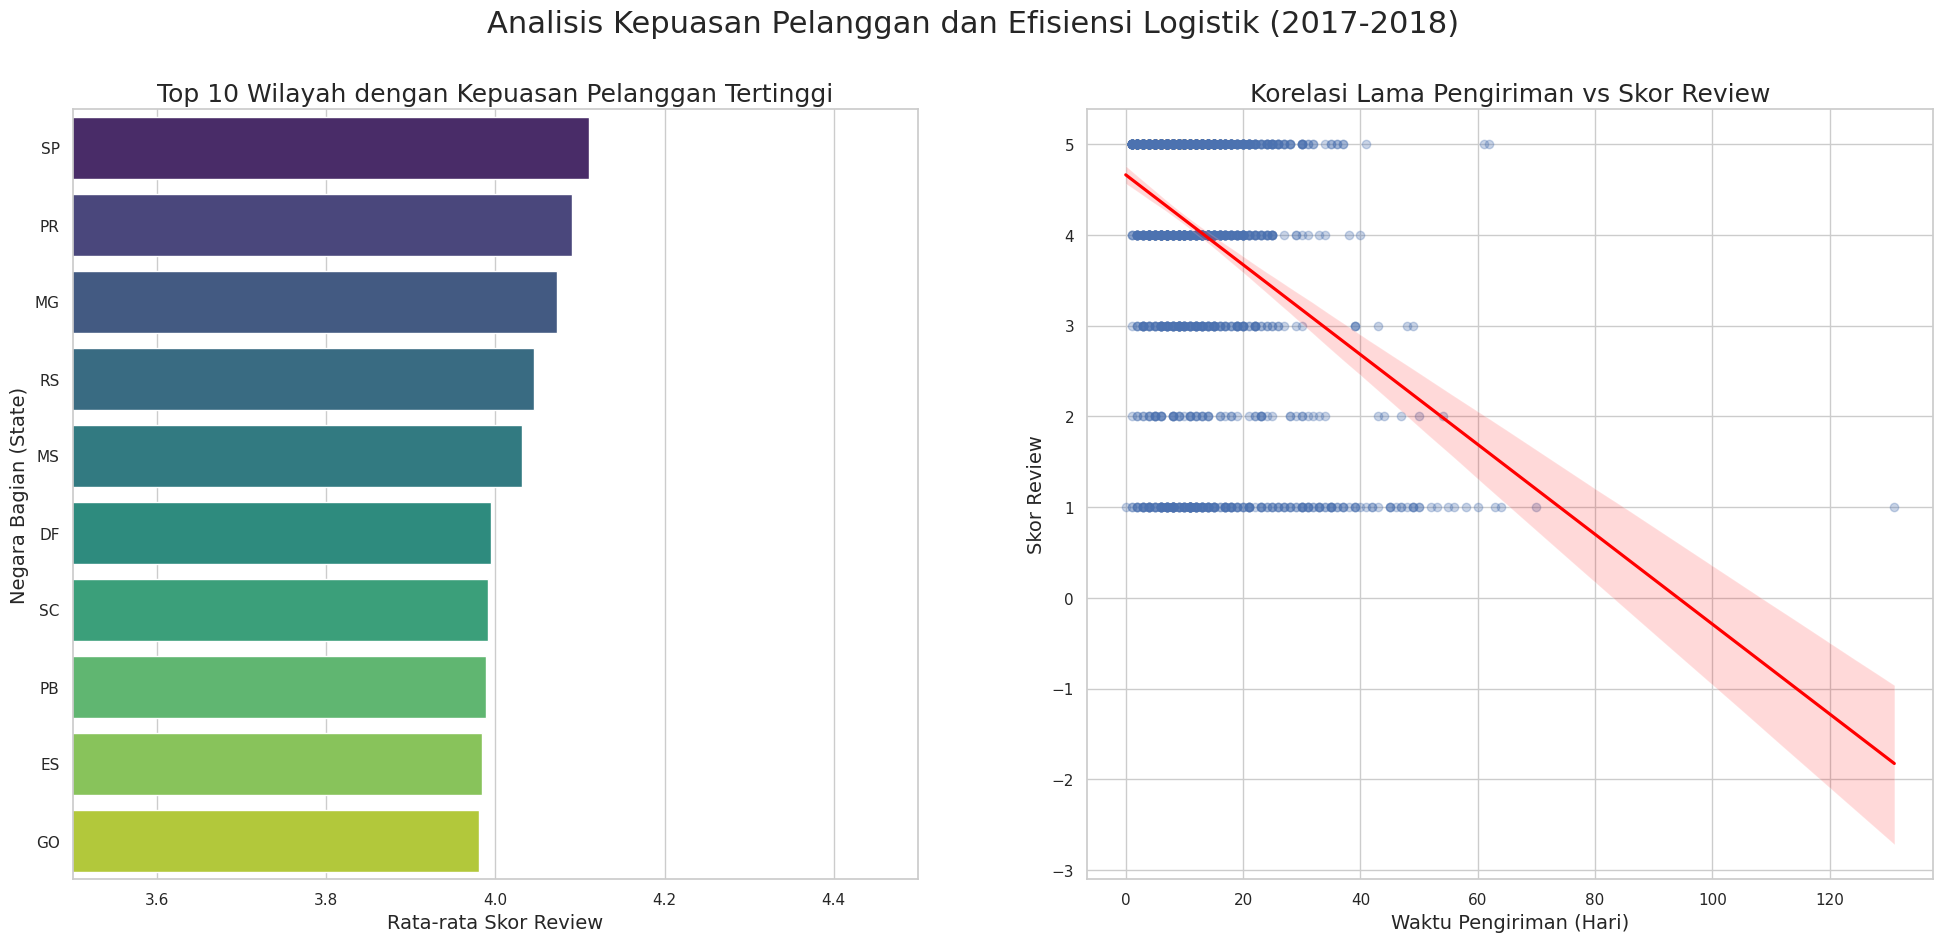

In [18]:
# 1. Menyiapkan data untuk analisis kepuasan per wilayah (State)
state_rating_df = all_df.groupby("customer_state").agg({
    "review_score": "mean",
    "customer_id": "nunique"
}).reset_index()

# Filter wilayah dengan jumlah pesanan yang signifikan (misal > 500) agar rata-rata lebih valid
state_rating_filtered = state_rating_df[state_rating_df["customer_id"] > 500].sort_values(by="review_score", ascending=False)

# 2. Menyiapkan data untuk korelasi pengiriman vs skor
# Kita gunakan kolom 'delivery_time' yang sudah dibuat di tahap EDA
# Menghapus data yang tidak memiliki informasi tanggal pengiriman (order belum sampai)
delivery_vs_score = all_df.dropna(subset=['delivery_time', 'review_score'])

# 3. Membuat visualisasi (Subplots)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Visualisasi A: Rata-rata Skor Review per Negara Bagian (Top 10)
sns.barplot(
    x="review_score",
    y="customer_state",
    data=state_rating_filtered.head(10),
    palette="viridis",
    hue="customer_state", # Mengatasi FutureWarning
    legend=False,         # Mengatasi FutureWarning
    ax=ax[0]
)
ax[0].set_title("Top 10 Wilayah dengan Kepuasan Pelanggan Tertinggi", loc="center", fontsize=18)
ax[0].set_xlabel("Rata-rata Skor Review", fontsize=14)
ax[0].set_ylabel("Negara Bagian (State)", fontsize=14)
ax[0].set_xlim(3.5, 4.5) # Zoom-in untuk melihat perbedaan lebih jelas

# Visualisasi B: Hubungan Lama Pengiriman dengan Skor Review
sns.regplot(
    x="delivery_time",
    y="review_score",
    data=delivery_vs_score.sample(2000, random_state=42), # Sample 2000 data agar plot tidak terlalu padat
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'},
    ax=ax[1]
)
ax[1].set_title("Korelasi Lama Pengiriman vs Skor Review", loc="center", fontsize=18)
ax[1].set_xlabel("Waktu Pengiriman (Hari)", fontsize=14)
ax[1].set_ylabel("Skor Review", fontsize=14)

plt.suptitle("Analisis Kepuasan Pelanggan dan Efisiensi Logistik (2017-2018)", fontsize=22)
plt.show()

**Insight:**
- xxx
- xxx

## Analisis Lanjutan (Opsional)

## Conclusion

#Conclusion Pertanyaan 1:
Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi dan memiliki volume penjualan terbanyak selama periode tahun 2017 hingga 2018?
Berdasarkan hasil analisis dan visualisasi data, dapat disimpulkan bahwa:

Kategori produk dengan pendapatan (revenue) tertinggi adalah health_beauty (kecantikan & kesehatan), diikuti oleh watches_gifts. Hal ini menunjukkan bahwa pelanggan cenderung menghabiskan uang lebih banyak pada produk-produk kategori gaya hidup dan perawatan diri.

Sementara itu, kategori dengan volume penjualan terbanyak (jumlah pesanan) adalah bed_bath_table.

Insight Utama: Terdapat perbedaan antara produk yang "paling banyak dibeli" dengan produk yang "paling banyak menghasilkan uang". Strategi pemasaran sebaiknya difokuskan pada kategori health_beauty untuk meningkatkan margin keuntungan, serta mempertahankan kategori bed_bath_table sebagai penarik trafik pelanggan.

#Conclusion Pertanyaan 2:
Bagaimana tingkat kepuasan pelanggan (review score) di berbagai wilayah, dan apakah terdapat korelasi antara lama waktu pengiriman dengan skor yang diberikan?
Analisis terhadap kepuasan pelanggan dan performa logistik menunjukkan:

Secara umum, tingkat kepuasan pelanggan cukup tinggi dengan mayoritas skor berada di angka 4.0 ke atas. Negara bagian seperti SP (Sao Paulo) dan MG (Minas Gerais) menunjukkan konsistensi antara volume pesanan yang besar dengan nilai kepuasan yang stabil.

Ditemukan adanya korelasi negatif yang jelas antara lama waktu pengiriman dengan skor review. Artinya, semakin lama durasi pengiriman, semakin rendah skor kepuasan yang diberikan oleh pelanggan.

Insight Utama: Kecepatan pengiriman adalah faktor krusial dalam mempertahankan loyalitas pelanggan. Perusahaan perlu menetapkan batas maksimal pengiriman (SLA) di bawah 20 hari untuk meminimalkan risiko mendapatkan review negatif (skor 1-2).